# Lab 4: Projected gradients and polygons
**Python supplement · Worked solutions · English**

Separate tangent motion from constraint restoration; numerically improve a convex polygon at fixed perimeter.

These two exercises supplement the mathematical lab; they are not
additional required work inside its original 90-minute schedule.
Allow roughly 60–90 minutes, depending on Python experience.

Run the setup cell first, then work from top to bottom. The task functions
are completed in this version. The demonstration cells generate the figures
and run mathematical checks; discussion guidance follows each exercise.

A plot, finite search or successful iteration supplies numerical
evidence. State separately any theorem used to establish existence,
global optimality or an equality case.


This version contains completed code and discussion guidance. All plots and checks can be reproduced with **Restart Kernel and Run All**.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.25,
                     'figure.constrained_layout.use': True})

def closed(v):
    """Repeat the first vertex only for plotting."""
    return np.vstack([v, v[0]])

def area(v):
    """Unsigned shoelace area of an ordered simple polygon."""
    return abs(np.sum(v[:, 0]*np.roll(v[:, 1], -1)
                      - v[:, 1]*np.roll(v[:, 0], -1)))/2

def perimeter(v):
    return np.linalg.norm(np.roll(v, -1, axis=0)-v, axis=1).sum()

def outline(ax, v, **kwargs):
    p = closed(v)
    ax.plot(p[:, 0], p[:, 1], **kwargs)
    ax.set_aspect('equal', adjustable='box')




## Exercise 4.1: Gradient ascent along an ellipse

Maximize $f(x,y)=x+2y$ subject to $g(x,y)=x^2+4y^2=1$.
At a feasible point, $a=\nabla f=(1,2)$ and $n=\nabla g=(2x,8y)$.
The tangent ascent direction is $d=a-(a\cdot n)n/(n\cdot n)$.

**Code tasks (30–40 minutes).**
1. Complete `ellipse_ascent(start, step, iterations)`: take $z=x+\eta d$,
   then restore feasibility with $x_{new}=z/\sqrt{z_1^2+4z_2^2}$.
2. Plot ambient and tangent gradient arrows and the iterate path.
3. Verify feasibility after every step, and compare the endpoint with
   $(1/\sqrt2,1/(2\sqrt2))$, where the maximum is $\sqrt2$.

**Return contract:** all iterates, including the initial point. Use the
supplied start `(1,0)` and step 0.1 before experimenting. The tangent step
alone is feasible only to first order. Retraction restores the equality
exactly up to roundoff; it is not asserted to be Euclidean projection.


In [2]:
def ellipse_ascent(start, step=0.1, iterations=300):
    x = np.array(start, dtype=float)
    x /= np.sqrt(x[0]**2+4*x[1]**2)
    history = [x.copy()]
    a = np.array([1., 2.])
    for _ in range(iterations):
        normal = np.array([2*x[0], 8*x[1]])
        direction = a-(a @ normal)/(normal @ normal)*normal
        trial = x+step*direction
        x = trial/np.sqrt(trial[0]**2+4*trial[1]**2)
        history.append(x.copy())
    return np.array(history)


**Run, visualize and check.** Adapt these plots as requested, and report what changes when you refine the discretization or vary parameters.

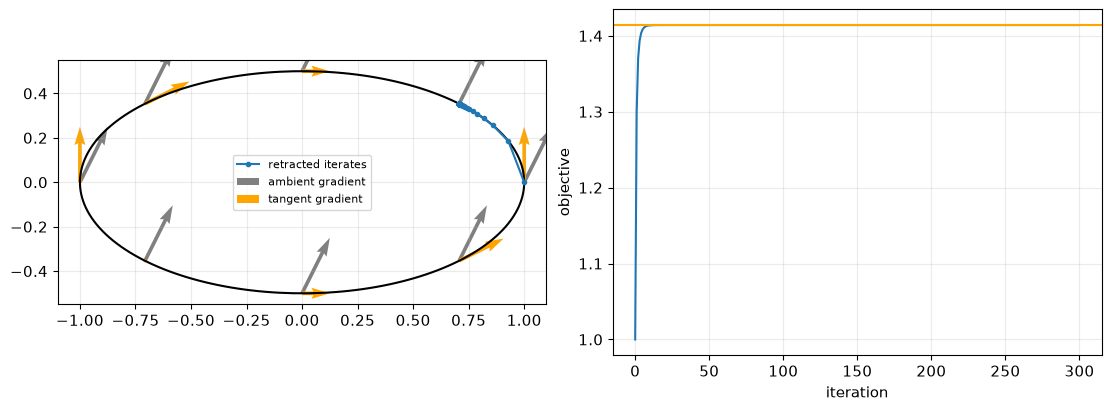

Largest constraint residual: 4.440892098500626e-16


In [3]:
path = ellipse_ascent([1., 0.])
if path is None:
    print('Complete ellipse_ascent, then rerun this cell.')
else:
    residual = path[:, 0]**2+4*path[:, 1]**2-1
    np.testing.assert_allclose(residual, 0, atol=1e-12)
    np.testing.assert_allclose(path[-1], [1/np.sqrt(2), 1/(2*np.sqrt(2))], atol=1e-6)
    t = np.linspace(0, 2*np.pi, 200)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(np.cos(t), .5*np.sin(t), 'k-')
    ax[0].plot(path[:, 0], path[:, 1], '.-', label='retracted iterates')
    angles = np.linspace(0, 2*np.pi, 9)[:-1]
    points = np.column_stack([np.cos(angles), .5*np.sin(angles)])
    normals = points*np.array([2., 8.])
    ambient = np.tile([1., 2.], (len(points), 1))
    tangent = ambient-((ambient*normals).sum(1)/(normals*normals).sum(1))[:, None]*normals
    np.testing.assert_allclose((tangent*normals).sum(1), 0, atol=1e-12)
    for vectors, color, label in [(ambient, 'gray', 'ambient gradient'), (tangent, 'orange', 'tangent gradient')]:
        ax[0].quiver(*points.T, *vectors.T, angles='xy', scale_units='xy', scale=8, color=color, label=label)
    ax[0].set_aspect('equal'); ax[0].legend(fontsize=8)
    ax[1].plot(path @ np.array([1., 2.])); ax[1].axhline(np.sqrt(2), color='orange')
    ax[1].set(xlabel='iteration', ylabel='objective'); plt.show()
    print('Largest constraint residual:', np.max(abs(residual)))


**Explain your observations.** At the maximum, why does the tangent gradient vanish while the ambient gradient does not? What could go wrong with a very large step?

**Solution guidance:** At the optimum the ambient gradient is normal to the constraint, so its tangent projection is zero. Tangent motion only preserves the constraint to first order. Retraction restores feasibility but does not make an arbitrarily large step an ascent step.

## Exercise 4.2: Improve a polygon at fixed perimeter

Represent a strictly convex counterclockwise $n$-gon by its vertices $v_i$.
The supplied helper returns $\nabla A$ and $\nabla P$. Use the tangent direction
$D=\nabla A-\langle\nabla A,\nabla P\rangle\nabla P/\|\nabla P\|^2$,
where the inner product sums over **all vertices and both coordinates**.

**Code tasks (40–50 minutes).**
1. Complete `polygon_ascent(start, L, iterations)`. Center and rescale the
   initial polygon to perimeter $L$. Take tangent steps and restore perimeter
   by centering and scaling again.
2. Backtrack from step 0.4 until the new polygon is strictly convex and
   its area increases by at least $10^{-4}\eta\|D\|^2$. Limit the search
   to 50 trials, and stop when $\|D\|<10^{-8}$.
3. Plot initial/final polygons and area history; compare with
   $L^2/[4n\tan(\pi/n)]$. Check side-length variation as well as objective error.

**Return contract:** `(final_vertices, area_history)` including the initial
area. Keep vertex order. The convexity guard checks that every vertex is
on the left of every oriented edge; a drawing alone is not a feasibility test.


**Provided helper code.** Run this cell before implementing the task.

In [4]:
def normalize(v, L):
    v = np.asarray(v, dtype=float)-np.mean(v, axis=0)
    return v*(L/perimeter(v))

def gradients(v):
    nxt, prev = np.roll(v,-1,axis=0), np.roll(v,1,axis=0)
    ga = .5*np.column_stack([nxt[:,1]-prev[:,1], prev[:,0]-nxt[:,0]])
    edges = nxt-v
    units = edges/np.linalg.norm(edges,axis=1)[:,None]
    gp = np.roll(units,1,axis=0)-units
    return ga, gp

def strictly_convex(v):
    edges = np.roll(v,-1,axis=0)-v
    delta = v[None,:,:]-v[:,None,:]
    side = edges[:,None,0]*delta[:,:,1]-edges[:,None,1]*delta[:,:,0]
    nxt = np.roll(edges,-1,axis=0)
    turns = edges[:,0]*nxt[:,1]-edges[:,1]*nxt[:,0]
    return bool(np.min(side) >= -1e-10 and np.min(turns) > 1e-10)


In [5]:
def polygon_ascent(start, L=6., iterations=2000):
    v = normalize(start, L)
    if not strictly_convex(v):
        raise ValueError('Start must be strictly convex and counterclockwise.')
    history = [area(v)]
    for _ in range(iterations):
        ga, gp = gradients(v)
        direction = ga-np.sum(ga*gp)/np.sum(gp*gp)*gp
        size2 = np.sum(direction*direction)
        if size2 < 1e-16:
            break
        step = .4
        for _ in range(50):
            trial = normalize(v+step*direction, L)
            if strictly_convex(trial) and area(trial) >= area(v)+1e-4*step*size2:
                break
            step *= .5
        else:
            # Near machine precision, failure to resolve an increase is not a proof of convergence.
            if np.sqrt(size2) < 1e-6:
                break
            raise RuntimeError('No feasible increasing step was found.')
        v = trial
        history.append(area(v))
    return v, np.array(history)


**Run, visualize and check.** Adapt these plots as requested, and report what changes when you refine the discretization or vary parameters.

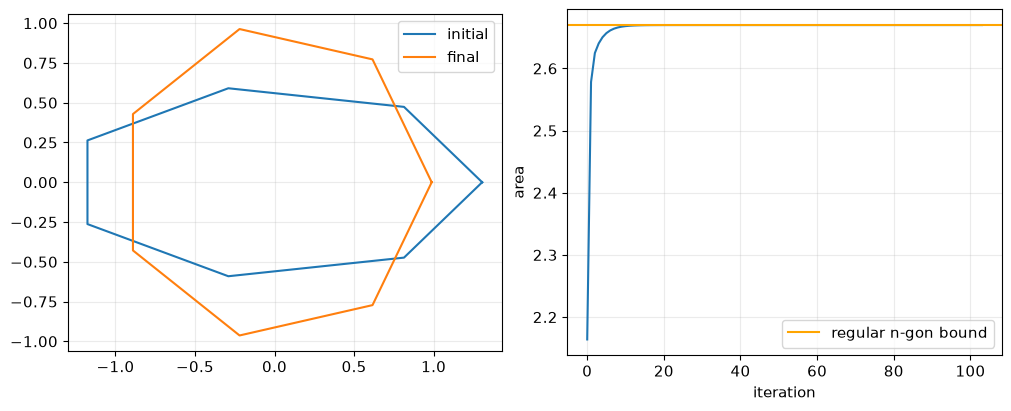

Area gap: -8.881784197001252e-16 relative side spread: 6.993253245009729e-08


In [6]:
n, L = 7, 6.
t = 2*np.pi*np.arange(n)/n
start = np.column_stack([1.4*np.cos(t), .65*np.sin(t)])
result = polygon_ascent(start, L)
if result is None:
    print('Complete polygon_ascent, then rerun this cell.')
else:
    final, values = result
    bound = L**2/(4*n*np.tan(np.pi/n))
    assert strictly_convex(final)
    np.testing.assert_allclose(perimeter(final), L, atol=1e-11)
    assert np.all(np.diff(values) >= -1e-12)
    assert 0 <= bound-area(final)+1e-12 < 1e-5
    # Independent directional finite-difference checks of the provided gradients.
    v = normalize(start, L)
    direction = np.random.default_rng(4).normal(size=v.shape)
    ga, gp = gradients(v)
    eps = 1e-6
    for functional, gradient in [(area, ga), (perimeter, gp)]:
        fd = (functional(v+eps*direction)-functional(v-eps*direction))/(2*eps)
        np.testing.assert_allclose(fd, np.sum(gradient*direction), rtol=1e-5, atol=1e-7)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    outline(ax[0], normalize(start,L), label='initial')
    outline(ax[0], final, label='final'); ax[0].legend()
    ax[1].plot(values); ax[1].axhline(bound, color='orange', label='regular n-gon bound')
    ax[1].set(xlabel='iteration', ylabel='area'); ax[1].legend(); plt.show()
    sides = np.linalg.norm(np.roll(final,-1,axis=0)-final, axis=1)
    print('Area gap:', bound-area(final), 'relative side spread:', np.ptp(sides)/sides.mean())


**Explain your observations.** Does this run prove convergence from every feasible starting polygon? Separate the numerical evidence from the polygonal theorem proved in Lab 4.

**Solution guidance:** The run preserves perimeter and convexity and approaches the regular-polygon bound. Finite convergence evidence from one start does not prove convergence from all starts. The independent theorem gives the global bound and equality case; the residual and side spread diagnose the numerical result.

**Before submitting:** restart the kernel, run all cells in order, check axis labels and units, and explain any discrepancy between numerical and exact quantities.